In [1]:
import pandas as pd
import tensorflow as tf

print("Libraries imported successfully")

Libraries imported successfully


# Part 2: Computer Vision Problem Formulation and CNN Prototype

In [2]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

This dataset represents an **Image Classification** problem.

In this dataset, each image belongs to one specific class:
- normal
- scratch
- dent
- stain

The goal of the model is to classify an input image into one of these four categories.

This is not an object detection or segmentation problem because:
- no bounding boxes are provided
- no pixel-level masks are available
- each image has only one main label

Therefore, image classification is the most appropriate computer vision problem type for this dataset.

# Task 2: Dataset Exploration

In [3]:
# Define dataset path

dataset_path = "images"

# Get class folder names
classes = os.listdir(dataset_path)

# Remove hidden system files if present
classes = [cls for cls in classes if not cls.startswith(".")]

# Sort class names
classes.sort()

# Display classes
print("Classes in dataset:")
print(classes)

Classes in dataset:
['dent', 'normal', 'scratch', 'stain']


In [4]:
# Count number of images in each class

class_counts = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    image_count = len(os.listdir(class_path))

    class_counts[cls] = image_count

# Display image counts
print("Number of images in each class:\n")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Number of images in each class:

dent: 120
normal: 120
scratch: 120
stain: 120


### Observation

The dataset contains 4 classes:
- dent
- normal
- scratch
- stain

Each class contains 120 images.

The dataset is balanced because all classes have equal number of images.

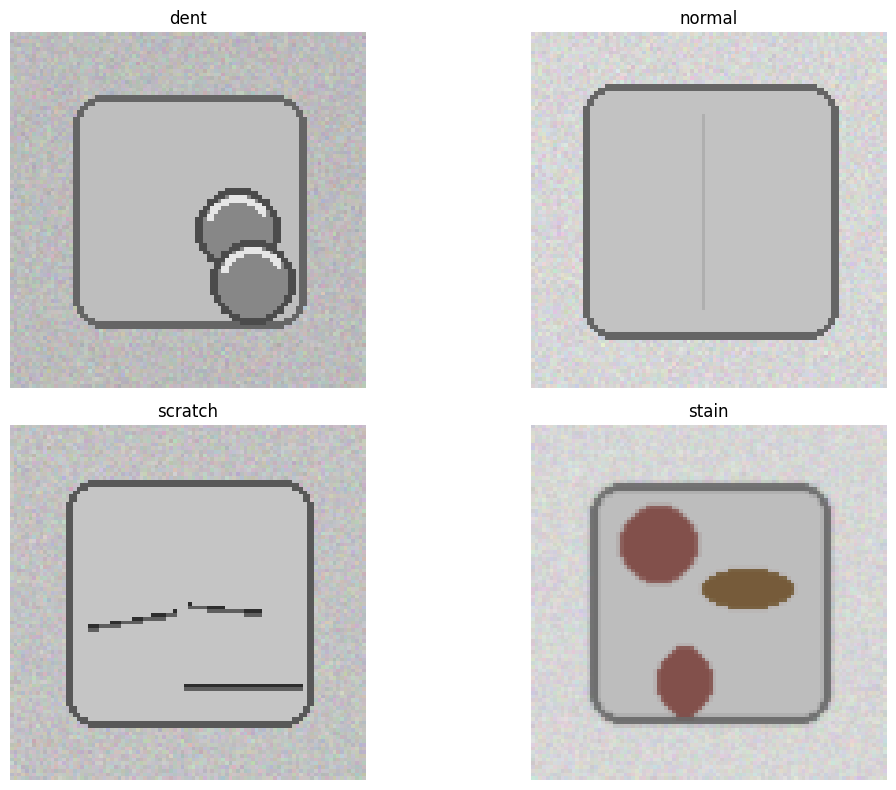

In [5]:
# Display one sample image from each class

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):

    # Get image folder path
    class_path = os.path.join(dataset_path, cls)

    # Get first image name
    image_name = os.listdir(class_path)[0]

    # Create full image path
    image_path = os.path.join(class_path, image_name)

    # Open image
    image = Image.open(image_path)

    # Plot image
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)

    # Add title
    plt.title(cls)

    # Remove axis
    plt.axis("off")

# Show all images
plt.tight_layout()
plt.show()

### Observation

The sample images clearly show visual differences between all four classes.

- dent images contain circular dent-like defects
- scratch images contain line-shaped scratches
- stain images contain colored stain marks
- normal images do not contain visible defects

The dataset is suitable for a CNN-based image classification problem because the patterns are visually distinguishable.

In [6]:
# Check image dimensions from one sample image of each class

print("Image dimensions:\n")

for cls in classes:

    # Get class folder path
    class_path = os.path.join(dataset_path, cls)

    # Get first image
    image_name = os.listdir(class_path)[0]

    # Create full image path
    image_path = os.path.join(class_path, image_name)

    # Open image
    image = Image.open(image_path)

    # Print image size
    print(f"{cls}: {image.size}")

Image dimensions:

dent: (96, 96)
normal: (96, 96)
scratch: (96, 96)
stain: (96, 96)


### Observation

All images in the dataset have the same dimensions:
- 96 × 96 pixels

Since all images already have a fixed size, preprocessing becomes easier for CNN training.

# Task 3: Image Preprocessing

In [7]:
# Import TensorFlow image preprocessing utilities

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
# Create image data generator with normalization and augmentation

train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

In [9]:
# Create training dataset

train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(96, 96),

    batch_size=32,

    class_mode="categorical",

    subset="training"
)

# Create validation dataset

validation_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(96, 96),

    batch_size=32,

    class_mode="categorical",

    subset="validation",
    shuffle=False
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [10]:
# Display class labels

print("Class indices:")

print(train_data.class_indices)

Class indices:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


### Observation

The dataset was successfully split into:
- 384 training images
- 96 validation images

Image normalization and augmentation were also applied.

TensorFlow automatically assigned numerical labels to the classes:
- dent → 0
- normal → 1
- scratch → 2
- stain → 3

# Task 4: CNN Model Creation

In [11]:
# Import CNN libraries

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [12]:
# Create CNN model

model = Sequential()

# First convolution layer
model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(96, 96, 3)
    )
)

# First pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution layer
model.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

# Second pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolution layer
model.add(
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    )
)

# Third pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout layer to reduce overfitting
model.add(Dropout(0.3))

# Output layer
model.add(Dense(4, activation='softmax'))

# Display model summary
model.summary()

/Users/jishantsingh/Documents/part-2-cnn-computer-vision/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

### CNN Model Summary

The CNN model contains:
- Convolution layers for feature extraction
- ReLU activation functions
- MaxPooling layers for dimensionality reduction
- Flatten layer to convert feature maps into 1D vector
- Dense layer for learning patterns
- Dropout layer to reduce overfitting
- Softmax output layer for multi-class classification

In [13]:
# Compile CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [14]:
# Train CNN model

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.2344 - loss: 1.4077 - val_accuracy: 0.2500 - val_loss: 1.3814
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.2708 - loss: 1.3611 - val_accuracy: 0.3958 - val_loss: 1.3108
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4688 - loss: 1.1977 - val_accuracy: 0.4896 - val_loss: 1.1056
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6198 - loss: 0.9341 - val_accuracy: 0.6458 - val_loss: 0.8211
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7031 - loss: 0.7320 - val_accuracy: 0.6979 - val_loss: 0.6852
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7734 - loss: 0.5840 - val_accuracy: 0.7708 - val_loss: 0.5113
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8151 - loss: 0.5187 - val_accuracy: 0.8125 - val_loss: 0.4807
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7578 - loss: 0.6202 - val_accuracy: 0.8438 - 

### Training Observation

The CNN model was trained for 20 epochs.

The model gradually learned visual patterns from the images and achieved good validation accuracy during training. Accuracy improved over epochs while loss decreased steadily. Small fluctuations in validation accuracy were observed because the dataset size is relatively small and image augmentation was applied during training.

In [15]:
# Import plotting library

import matplotlib.pyplot as plt

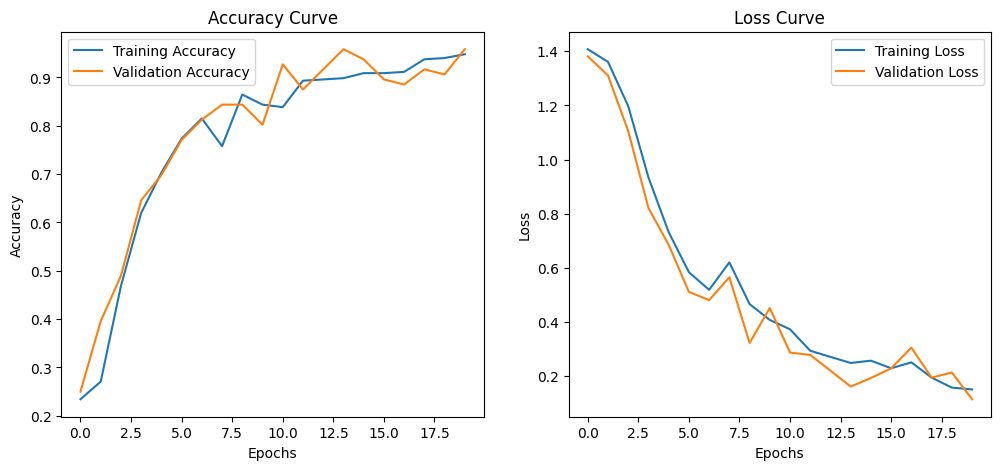

In [16]:
# Plot training and validation accuracy

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

# Loss graph
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

# Save figure in results folder
plt.savefig("results/accuracy_loss_curves.png")

# Display plot
plt.show()

### Accuracy and Loss Curves

The training and validation graphs show how the CNN model learned during training.

Training accuracy and validation accuracy improved gradually over epochs, while training loss and validation loss decreased steadily. Minor fluctuations can be observed in validation metrics because the dataset size is relatively small. Overall, the model achieved good performance on the image classification task.

In [17]:
# Evaluate CNN model on validation data

test_loss, test_accuracy = model.evaluate(validation_data)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9375 - loss: 0.1638
Test Loss: 0.163777694106102
Test Accuracy: 0.9375


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


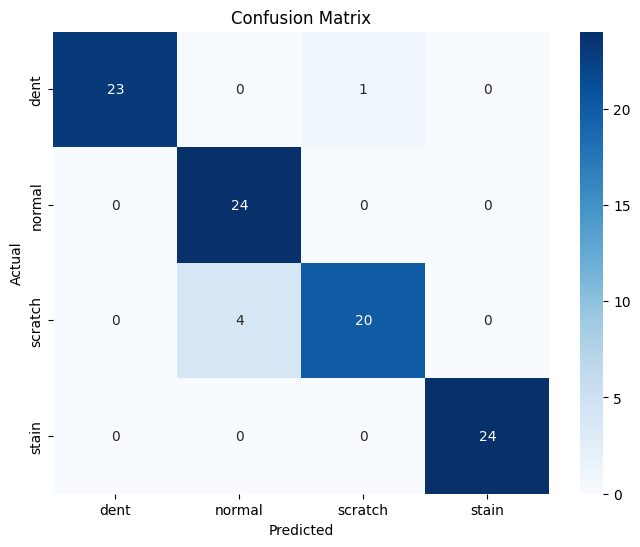

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.86      1.00      0.92        24
           2       0.95      0.83      0.89        24
           3       1.00      1.00      1.00        24

    accuracy                           0.95        96
   macro avg       0.95      0.95      0.95        96
weighted avg       0.95      0.95      0.95        96



In [18]:
# Import libraries
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get true labels
true_labels = validation_data.classes

# Predict classes
predictions = model.predict(validation_data)

predicted_labels = np.argmax(predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_data.class_indices.keys(),
    yticklabels=validation_data.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save figure
plt.savefig("results/confusion_matrix.png")

plt.show()

# Print classification report
print(classification_report(true_labels, predicted_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


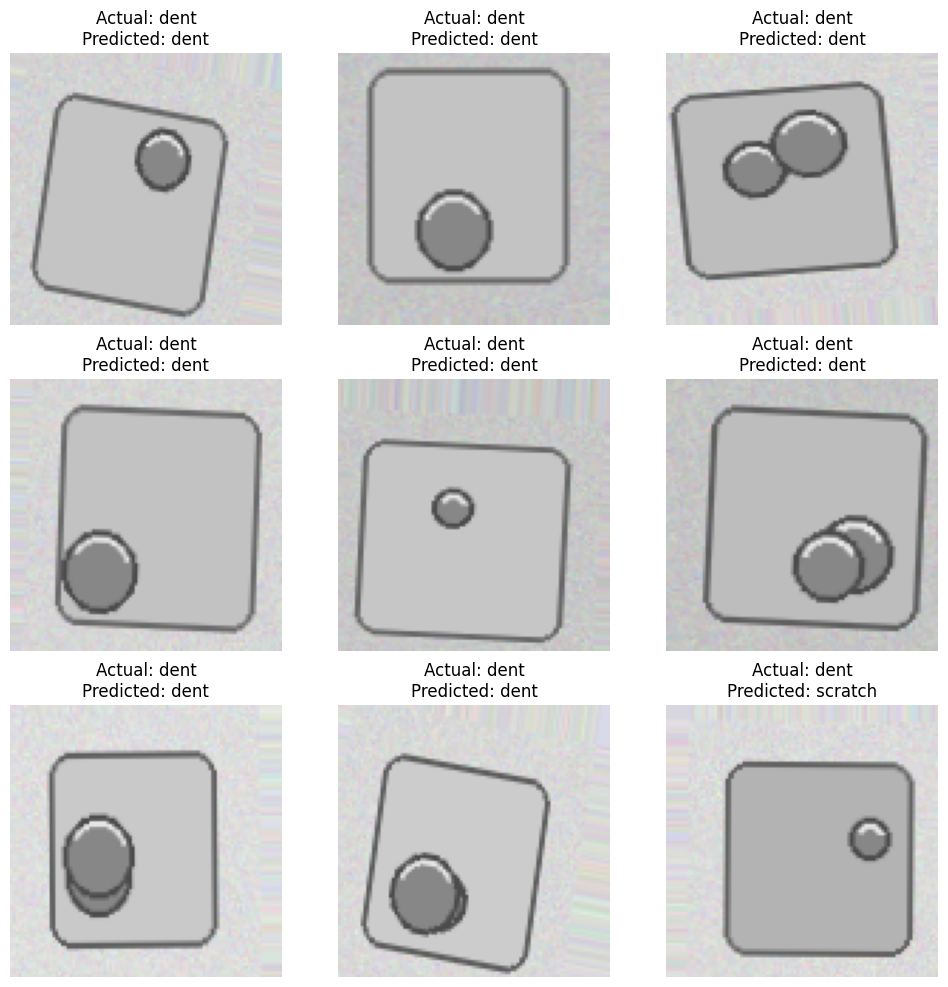

In [19]:
# Import libraries
import random

# Get class names
class_names = list(validation_data.class_indices.keys())

# Get random batch
images, labels = next(validation_data)

# Predict on images
predictions = model.predict(images)

# Create figure
plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    # Actual label
    actual_label = class_names[np.argmax(labels[i])]

    # Predicted label
    predicted_label = class_names[np.argmax(predictions[i])]

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")

    plt.axis("off")

# Save figure
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()